In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)



c:\Users\priya\anaconda3\envs\toxicity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# 1. DATA PROCESSING PIPELINE
# =========================================================
class DataPipeline:
    def __init__(self, text_cols, target_col):
        self.text_cols = text_cols
        self.target_col = target_col

    def load_and_clean(self, filepath):
        """Loads data and handles missing text natively."""
        df = pd.read_csv(filepath)
        for col in self.text_cols:
            df[col] = df[col].fillna("missing_text")
        return df

    def create_pool(self, df):
        """Wraps data into CatBoost Pools mapping text features securely."""
        return Pool(
            data=df[self.text_cols],
            label=df[self.target_col].values,
            text_features=self.text_cols
        )



In [3]:
# =========================================================
# 2. MODELING PIPELINE (After - Gatekeeper Config)
# =========================================================
def build_toxicity_pipeline(text_cols, pos_weight):
    """
    Constructs a scikit-learn Pipeline with the Gatekeeper CatBoost config.
    """
    catboost_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        scale_pos_weight=pos_weight,
        eval_metric='AUC:hints=skip_train~false', # Track AUC explicitly
        early_stopping_rounds=50,
        task_type="GPU", # Hardware acceleration
        verbose=50,
        random_seed=42,
        text_features=text_cols # CRITICAL: Tells the Pipeline to map text strings properly
    )
    
    pipeline = Pipeline(steps=[
        ('classifier', catboost_model)
    ])
    
    return pipeline

In [4]:
# =========================================================
# 3. EVALUATION FUNCTIONS (Class-free)
# =========================================================
def plot_threshold_curves(y_true, y_probs, dataset_name="Validation"):
    """Plots Precision, Recall, and F1 across all thresholds 0-1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 safely
    f1_scores = np.divide(
        2 * (precision * recall), 
        (precision + recall), 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precision[:-1], label='Precision', color='#1f77b4', linestyle='--')
    plt.plot(thresholds, recall[:-1], label='Recall', color='#ff7f0e', linestyle='-.')
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='#2ca02c', linewidth=2.5)
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    
    plt.title(f'{dataset_name}: Metrics vs. Classification Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()
    
    return best_threshold

def plot_dual_confusion_matrix(y_val, y_val_pred, y_test, y_test_pred):
    """Side-by-side CM for Validation and Test datasets."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_val = confusion_matrix(y_val, y_val_pred)
    ConfusionMatrixDisplay(cm_val, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Validation Confusion Matrix")
    
    cm_test = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm_test, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[1], cmap='Greens', colorbar=False)
    axes[1].set_title("Test Confusion Matrix")
    
    plt.tight_layout()
    plt.show()

Loading data...
Calculated pos_weight: 11.51
🚀 Initializing Gatekeeper Pipeline...
🚀 Training Gatekeeper on GPU...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	learn: 0.8014062	test: 0.8335875	best: 0.8335875 (0)	total: 25.3ms	remaining: 12.6s
50:	learn: 0.8429538	test: 0.8710282	best: 0.8710282 (50)	total: 680ms	remaining: 5.98s
100:	learn: 0.8552078	test: 0.8765695	best: 0.8765695 (100)	total: 1.29s	remaining: 5.12s
150:	learn: 0.8650943	test: 0.8781157	best: 0.8781157 (150)	total: 1.91s	remaining: 4.41s
200:	learn: 0.8727531	test: 0.8786474	best: 0.8786592 (191)	total: 2.53s	remaining: 3.76s
250:	learn: 0.8788343	test: 0.8784907	best: 0.8787232 (213)	total: 3.18s	remaining: 3.16s
bestTest = 0.8787232041
bestIteration = 213
Shrink model to first 214 iterations.

--- Threshold Analysis ---


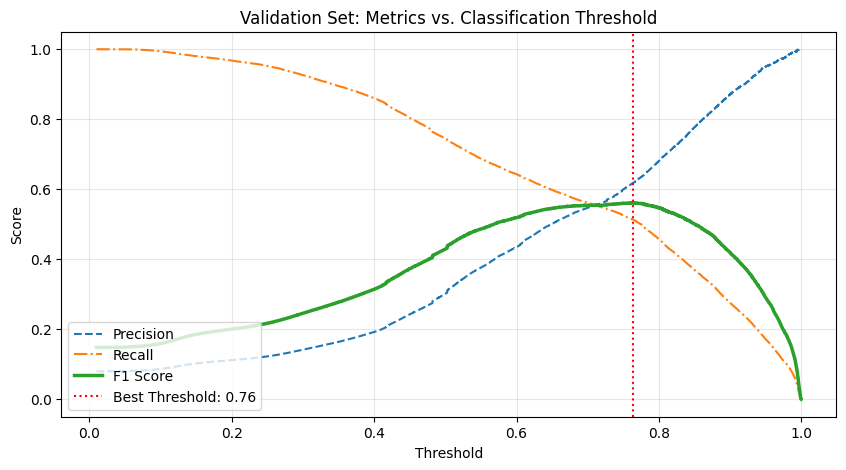

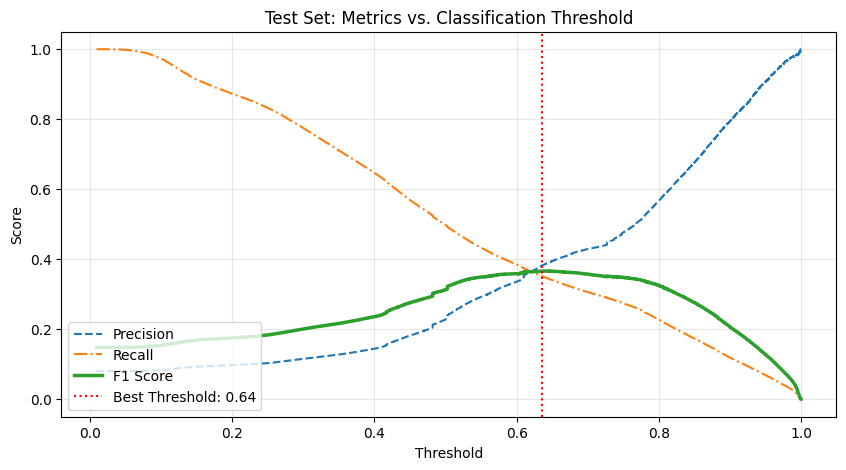


--- Confusion Matrices ---


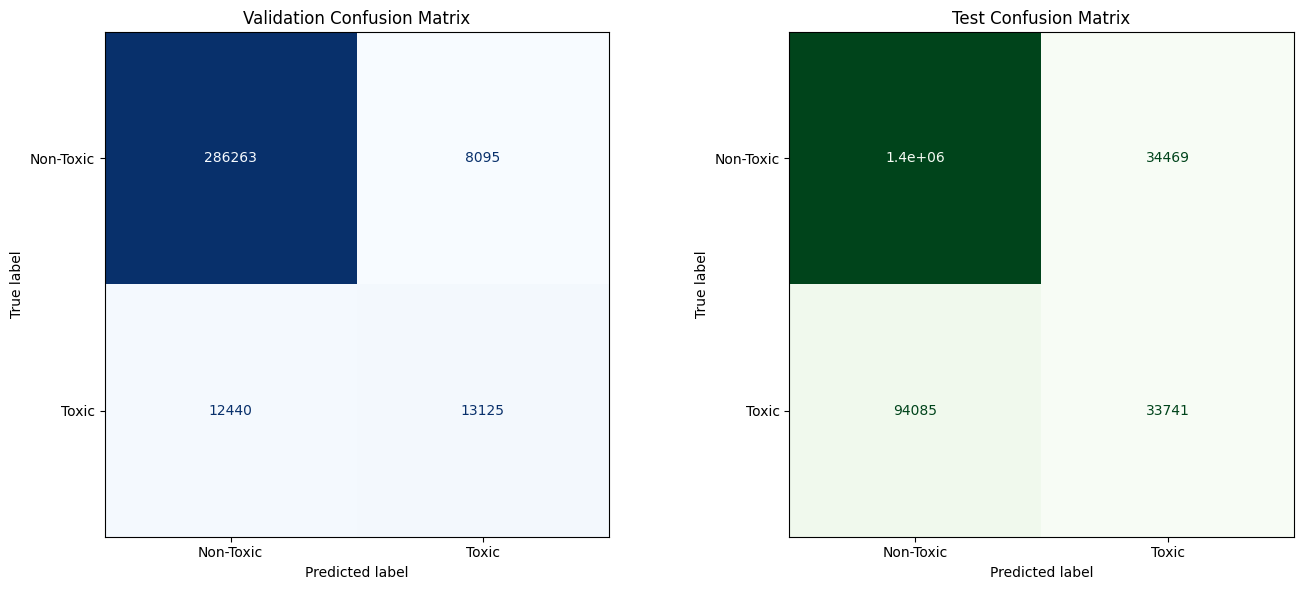

In [5]:
# =========================================================
# 4. MAIN EXECUTION
# =========================================================
# %%
if __name__ == "__main__":
    # 1. Configuration
    TEXT_COLS = ['comment_text']
    TARGET_COL = 'toxicity'
    
    # 2. Load Data (Using basic pandas read_csv for brevity)
    print("Loading data...")
    train_df = pd.read_csv("data/input/train_split.csv").fillna({c: "missing_text" for c in TEXT_COLS})
    val_df = pd.read_csv("data/input/val_split.csv").fillna({c: "missing_text" for c in TEXT_COLS})
    test_df = pd.read_csv("data/input/test_split.csv").fillna({c: "missing_text" for c in TEXT_COLS})
    
    # Calculate pos_weight for the Gatekeeper model
    # Formula: (Count of Negative Class) / (Count of Positive Class)
    neg_count = (train_df[TARGET_COL] == 0).sum()
    pos_count = (train_df[TARGET_COL] == 1).sum()
    pos_weight = neg_count / pos_count
    print(f"Calculated pos_weight: {pos_weight:.2f}")
    
    # Build scikit-learn Pipeline with Gatekeeper config
    print("🚀 Initializing Gatekeeper Pipeline...")
    toxicity_pipeline = build_toxicity_pipeline(
        text_cols=TEXT_COLS, 
        pos_weight=pos_weight
    )
    
    # Train Model (early_stopping is now handled in the init)
    print("🚀 Training Gatekeeper on GPU...")
    toxicity_pipeline.fit(
        train_df[TEXT_COLS], 
        train_df[TARGET_COL],
        classifier__eval_set=(val_df[TEXT_COLS], val_df[TARGET_COL]),
        classifier__use_best_model=True
    )
    
    # 5. Predict Probabilities directly from Pipeline
    val_probs = toxicity_pipeline.predict_proba(val_df[TEXT_COLS])[:, 1]
    test_probs = toxicity_pipeline.predict_proba(test_df[TEXT_COLS])[:, 1]
    
    # 6. Evaluate Thresholds
    print("\n--- Threshold Analysis ---")
    optimal_threshold = plot_threshold_curves(val_df[TARGET_COL], val_probs, "Validation Set")
    _ = plot_threshold_curves(test_df[TARGET_COL], test_probs, "Test Set")
    
    # Apply optimal threshold
    val_preds = (val_probs >= optimal_threshold).astype(int)
    test_preds = (test_probs >= optimal_threshold).astype(int)
    
    # 7. Plot Dual Confusion Matrices
    print("\n--- Confusion Matrices ---")
    plot_dual_confusion_matrix(
        y_val=val_df[TARGET_COL], y_val_pred=val_preds,
        y_test=test_df[TARGET_COL], y_test_pred=test_preds
    )